In [1]:
import numpy as np
import pandas as pd
import random
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler, MaxAbsScaler
from sklearn.metrics import accuracy_score, balanced_accuracy_score, precision_score, recall_score, fbeta_score, log_loss, confusion_matrix 
from sklearn.impute import KNNImputer
from imblearn.under_sampling import NearMiss 
from imblearn.over_sampling import BorderlineSMOTE
import sys
import math
import shap

sys.path.insert(0, "../../../../Modules")

pd.set_option('display.max_columns', None)
random.seed(0)
np.random.seed(0)

from utils import *

import warnings
warnings.filterwarnings("ignore")

In [2]:
NUTS0 = 'GR'
NUTS2 = 'Thessaly'

Q = 'Q1'
q = Q.lower()

In [3]:
path = f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_Dataset_Q1_2011_2022.csv'

dataset = read_data(path)
dataset.head()

,year,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,min_temp_q1,mean_temp_q1,max_temp_q1,prec_q1,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,ndvi_q1,ndwi_q1,ndmi_q1,ndbi_q1,ndvi_mean_q1,ndwi_mean_q1,ndmi_mean_q1,ndbi_mean_q1,ndvi_std_q1,ndwi_std_q1,ndmi_std_q1,ndbi_std_q1,M_TOTAL,M_Y_LT_15,M_Y15-64,M_Y_GE65,F_TOTAL,F_Y_LT_15,F_Y15-64,F_Y_GE65,MIO_EUR,L_TOTAL,UNL_TOTAL,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,qc,culex_pipiens,WNV_cases
0,2011,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",21.719540,39.504234,3.686851,5.948136,8.265869,14.428439,15.333333,19.166667,46.747967,795.536792,38.0,-3.0,41.0,15.000000,25.500000,25.500000,6.000000,2002.0,348.0,9.0,63.000736,812.0,142.0,142.0,702.0,0.247676,0.124756,0.332002,-0.332002,0.250039,0.109395,0.319940,-0.319940,0.050979,0.086203,0.061957,0.061957,123067.0,17404.0,77291.0,28372.0,126854.0,16953.0,74300.0,35601.0,3007.13,10080.6,10176.8,17975.604018,1711.707054,3.0,138.640321,118.625259,179.448305,0.0,3.287901,22.0,9.0,20.0,13.0,13.0,10.0,8.0,9.0,2.0,9.0,5230.598616,1
1,2011,EL61,θεσσαλια,EL612,λαρισα,22.405497,39.703383,4.875334,7.672218,10.319188,10.048595,17.291667,21.583333,47.962963,881.233210,42.0,-3.0,45.0,17.166667,28.333333,28.333333,6.666667,1371.0,275.0,22.0,62.577013,550.0,158.0,158.0,378.0,0.294055,0.019309,0.273389,-0.273389,0.299809,0.018538,0.280083,-0.280083,0.042559,0.047435,0.047199,0.047199,143485.0,23344.0,94158.0,25983.0,146791.0,22094.0,93589.0,31108.0,4654.45,6268.6,6460.0,20223.103890,2095.505327,0.0,123.340767,73.893361,179.979366,0.0,2.597098,31.0,36.0,30.0,12.0,12.0,1.0,6.0,7.0,2.0,0.0,4285.480144,1
2,2011,EL61,θεσσαλια,EL613,"μαγνησια, σποραδες",22.869212,39.281871,5.750763,8.008002,10.354182,15.117940,17.333333,19.000000,46.341463,808.571505,40.0,-1.0,41.0,17.000000,27.666667,27.666667,7.833333,1243.0,266.0,10.0,67.794059,476.0,129.0,129.0,391.0,0.337567,0.009852,0.289970,-0.289970,0.329326,0.020087,0.296028,-0.296028,0.046129,0.075248,0.053855,0.053855,101047.0,15287.0,68105.0,17655.0,105732.0,14898.0,67890.0,22944.0,3102.99,6268.6,6460.0,3349.163297,962.563555,2.0,115.090911,25.935036,177.527387,0.0,3.315256,22.0,20.0,20.0,9.0,9.0,4.0,1.0,1.0,2.0,0.0,2948.510417,1
3,2012,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",21.719540,39.504234,1.038181,4.630964,10.593495,14.288565,13.958333,19.250000,49.358974,841.929152,35.0,-4.0,39.0,3.833333,24.333333,24.333333,3.833333,1223.0,212.0,2.0,63.539911,472.0,91.0,91.0,472.0,0.218565,0.035023,0.214999,-0.214999,0.210467,0.056554,0.228696,-0.228696,0.049441,0.090672,0.068613,0.068613,123287.0,17312.0,77199.0,28776.0,126475.0,16778.0,73914.0,35783.0,2698.51,10080.6,10176.8,17975.604018,1711.707054,3.0,138.640321,118.625259,179.448305,0.0,3.287901,22.0,9.0,20.0,13.0,13.0,10.0,8.0,9.0,2.0,9.0,5014.138408,0
4,2012,EL61,θεσσαλια,EL612,λαρισα,22.405497,39.703383,2.947811,6.688539,12.883651,9.134991,15.916667,22.500000,48.913043,906.249347,42.0,-4.0,46.0,10.166667,27.333333,27.333333,5.666667,928.0,123.0,4.0,50.136650,314.0,136.0,136.0,284.0,0.227105,-0.092324,0.108107,-0.108107,0.228260,-0.110236,0.093846,-0.093846,0.048894,0.066280,0.057066,0.057066,143171.0,23273.0,93519.0,26379.0,147118.0,22079.0,93390.0,31649.0,4125.73,6268.6,6460.0,20223.103890,2095.505327,0.0,123.340767,73.893361,179.979366,0.0,2.597098,31.0,36.0,30.0,12.0,12.0,1.0,6.0,7.0,2.0,0.0,4641.090253,0


In [4]:
dataset.shape

(166, 73)

In [5]:
## Simple output binarization

# dataset.drop_duplicates(keep='first', inplace=True, ignore_index=True)
# dataset

In [6]:
dataset.columns

Index(['year', 'NUTS2_ID', 'NUTS2_NAME', 'NUTS3_ID', 'NUTS3_NAME', 'x', 'y',
       'min_temp_q1', 'mean_temp_q1', 'max_temp_q1', 'prec_q1', 'bio1', 'bio2',
       'bio3', 'bio4', 'bio5', 'bio6', 'bio7', 'bio8', 'bio9', 'bio10',
       'bio11', 'bio12', 'bio13', 'bio14', 'bio15', 'bio16', 'bio17', 'bio18',
       'bio19', 'ndvi_q1', 'ndwi_q1', 'ndmi_q1', 'ndbi_q1', 'ndvi_mean_q1',
       'ndwi_mean_q1', 'ndmi_mean_q1', 'ndbi_mean_q1', 'ndvi_std_q1',
       'ndwi_std_q1', 'ndmi_std_q1', 'ndbi_std_q1', 'M_TOTAL', 'M_Y_LT_15',
       'M_Y15-64', 'M_Y_GE65', 'F_TOTAL', 'F_Y_LT_15', 'F_Y15-64', 'F_Y_GE65',
       'MIO_EUR', 'L_TOTAL', 'UNL_TOTAL', 'distance_to_coast',
       'distance_to_river', 'slope_mean_1km', 'aspect_mean_200m',
       'elevation_mean_1km', 'hillshade_mean_1km', 'fs_area_1km',
       'flow_accu_200m', 'lc_prop1', 'lc_prop2', 'lc_prop3', 'lc_type1',
       'lc_type2', 'lc_type3', 'lc_type4', 'lc_type5', 'lw', 'qc',
       'culex_pipiens', 'WNV_cases'],
      dtype='objec

In [7]:
print(f'Number of NUTS3 Units in dataset: {len(dataset.NUTS3_NAME.unique())}')

Number of NUTS3 Units in dataset: 3


In [8]:
dsc = dataframe_describe(dataset, target_column = 'WNV_cases')
dsc.head(15)

,year,non-case,case,total,percentage
0,2011,0,30,30,18.07%
1,2012,3,0,3,1.81%
2,2013,3,0,3,1.81%
3,2014,3,0,3,1.81%
4,2015,3,0,3,1.81%
5,2016,3,0,3,1.81%
6,2017,3,0,3,1.81%
7,2018,2,7,9,5.42%
8,2019,1,53,54,32.53%
9,2020,1,10,11,6.63%


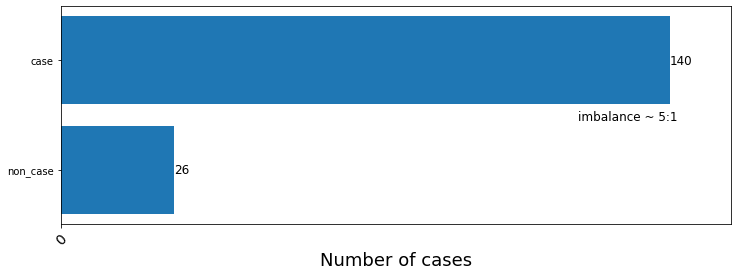

In [9]:
plot_imbalance(dataset, target_column='WNV_cases')

In [10]:
majority_class = 1
near_u = 0
smote = 2
scaler = 'minmax'
weight_multiplier = 1

years_to_remove = []

features_to_remove = ['x', 'y', 'year', 'distance_to_coast',
       'distance_to_river', 'slope_mean_1km', 'aspect_mean_200m',
       'elevation_mean_1km', 'hillshade_mean_1km', 'fs_area_1km',
       'flow_accu_200m', 'lc_prop1', 'lc_prop2', 'lc_prop3', 'lc_type1',
       'lc_type2', 'lc_type3', 'lc_type4', 'lc_type5', 'lw', 'qc',]

# geo_vars
# features_to_remove = ['x', 'y', 'year', 'lc_type1', 'lc_type3', 'lc_type4', 'lc_type5','lw', 'qc',]

#features_to_remove=[]
#years_to_remove = []

In [11]:
model_coefficients = []
model_shaps = []
results_train = pd.DataFrame()
results_test = pd.DataFrame()
feature_names = dataset.select_dtypes(exclude=['object']).drop(columns = ['WNV_cases'] 
                                                               + features_to_remove).columns

print(feature_names)

Index(['min_temp_q1', 'mean_temp_q1', 'max_temp_q1', 'prec_q1', 'bio1', 'bio2',
       'bio3', 'bio4', 'bio5', 'bio6', 'bio7', 'bio8', 'bio9', 'bio10',
       'bio11', 'bio12', 'bio13', 'bio14', 'bio15', 'bio16', 'bio17', 'bio18',
       'bio19', 'ndvi_q1', 'ndwi_q1', 'ndmi_q1', 'ndbi_q1', 'ndvi_mean_q1',
       'ndwi_mean_q1', 'ndmi_mean_q1', 'ndbi_mean_q1', 'ndvi_std_q1',
       'ndwi_std_q1', 'ndmi_std_q1', 'ndbi_std_q1', 'M_TOTAL', 'M_Y_LT_15',
       'M_Y15-64', 'M_Y_GE65', 'F_TOTAL', 'F_Y_LT_15', 'F_Y15-64', 'F_Y_GE65',
       'MIO_EUR', 'L_TOTAL', 'UNL_TOTAL', 'culex_pipiens'],
      dtype='object')


In [12]:
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=0)
x = dataset.drop(columns = ['WNV_cases'])
y = dataset['WNV_cases']
fold = 0
  
for train_idx, test_idx in skf.split(x, y):
    data_train = dataset.iloc[train_idx]
    data_test = dataset.iloc[test_idx]
    data_test = data_test.drop_duplicates(keep='first')
    if len(years_to_remove) > 0:
        data_train = data_train.loc[~data_train['year'].isin(years_to_remove)]
    
    data_train.reset_index(inplace = True, drop = True)
    data_test.reset_index(inplace = True, drop = True)
    
    X_train, X_test, y_train, y_test, scaler, imputer = train_test_split_transform(data_train, data_test, near_u, smote, 'WNV_cases', scaler, majority_class, features_to_remove)

    w0,w1 = calculate_weights_new(y_train, weight_multiplier)

    model = LogisticRegression(max_iter = 1000, class_weight = {0.0: w0, 1.0:w1}, n_jobs = -1, random_state = 0)

    trained_model, model_shap = train_lin_model(model, X_train, y_train, explain=True)

    train, test, coef = predict_lin_model_new(trained_model, X_train, y_train, X_test, y_test, data_test, day_col = None, month_col = None, spatial_col = 'NUTS3_NAME')

    results_train = results_train.append(train, ignore_index = True)
    results_test = results_test.append(test, ignore_index = True)
    model_coefficients.append(coef)
    model_shaps.append(model_shap)
    
    print(f"Fold: {fold} || w0:{w0}, w1:{w1} || ##")
    fold = fold + 1

shap_values= np.concatenate(model_shaps, axis=0)

Fold: 0 || w0:2, w1:1 || ##
Fold: 1 || w0:2, w1:1 || ##
Fold: 2 || w0:2, w1:1 || ##
Fold: 3 || w0:2, w1:1 || ##
Fold: 4 || w0:2, w1:1 || ##
Fold: 5 || w0:2, w1:1 || ##
Fold: 6 || w0:2, w1:1 || ##
Fold: 7 || w0:2, w1:1 || ##
Fold: 8 || w0:2, w1:1 || ##
Fold: 9 || w0:2, w1:1 || ##


In [13]:
feature_names

Index(['min_temp_q1', 'mean_temp_q1', 'max_temp_q1', 'prec_q1', 'bio1', 'bio2',
       'bio3', 'bio4', 'bio5', 'bio6', 'bio7', 'bio8', 'bio9', 'bio10',
       'bio11', 'bio12', 'bio13', 'bio14', 'bio15', 'bio16', 'bio17', 'bio18',
       'bio19', 'ndvi_q1', 'ndwi_q1', 'ndmi_q1', 'ndbi_q1', 'ndvi_mean_q1',
       'ndwi_mean_q1', 'ndmi_mean_q1', 'ndbi_mean_q1', 'ndvi_std_q1',
       'ndwi_std_q1', 'ndmi_std_q1', 'ndbi_std_q1', 'M_TOTAL', 'M_Y_LT_15',
       'M_Y15-64', 'M_Y_GE65', 'F_TOTAL', 'F_Y_LT_15', 'F_Y15-64', 'F_Y_GE65',
       'MIO_EUR', 'L_TOTAL', 'UNL_TOTAL', 'culex_pipiens'],
      dtype='object')

In [14]:
len(feature_names)

47

In [15]:
bioclimatic = ['bio1','bio2','bio3','bio4','bio5','bio6','bio7','bio8','bio9','bio10','bio11','bio12','bio13','bio14','bio15','bio16','bio17','bio18','bio19']
climate = [f'min_temp_{q}', f'mean_temp_{q}', f'max_temp_{q}', f'prec_{q}']
enviromental = [f'ndvi_{q}',f'ndwi_{q}',f'ndmi_{q}',f'ndbi_{q}',f'ndvi_mean_{q}',f'ndwi_mean_{q}',f'ndmi_mean_{q}',f'ndbi_mean_{q}',f'ndvi_std_{q}',f'ndwi_std_{q}',f'ndmi_std_{q}',f'ndbi_std_{q}']
demographic = ['M_TOTAL','M_Y_LT_15','M_Y15-64','M_Y_GE65','F_TOTAL','F_Y_LT_15','F_Y15-64','F_Y_GE65']
vectors = ['culex_pipiens']
trade = ['L_TOTAL',	'UNL_TOTAL']
economic = ['MIO_EUR']

In [16]:
len(bioclimatic+climate+enviromental+demographic+vectors+trade+economic)

47

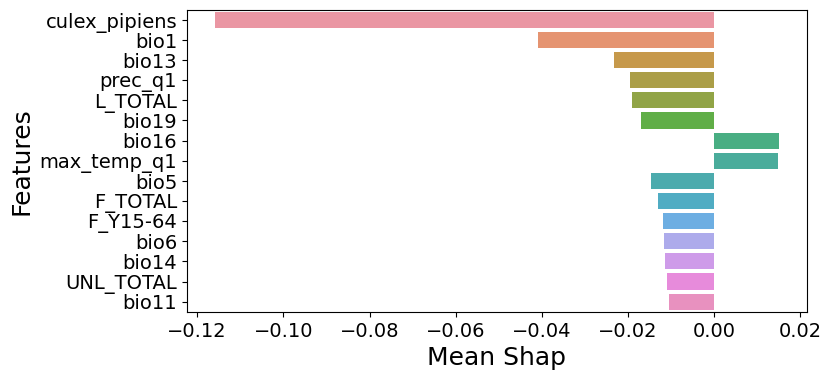

In [17]:
mean_shap = shap_values.mean(axis=0)
shp = mean_shap.shape[0]
mean_shap = mean_shap.reshape(1,shp)

shaps = plot_feature_importance(mean_shap, feature_names, x_label = 'Mean Shap', top = 15, figure_size = (8, 4))

shaps['weights_abs'] = shaps['weights'].apply(lambda x: abs(x))

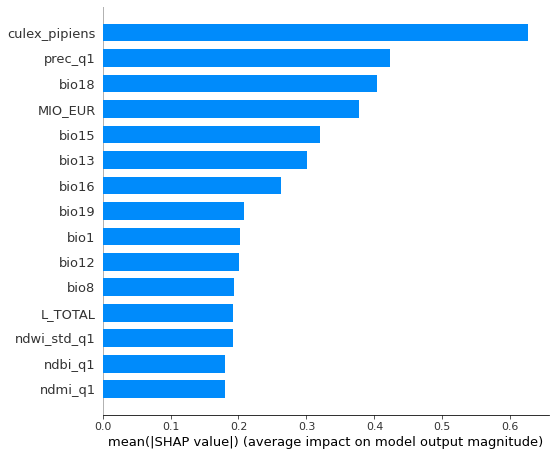

In [18]:
shap.summary_plot(shap_values, features = X_train, feature_names = feature_names, plot_type='bar', max_display=15)

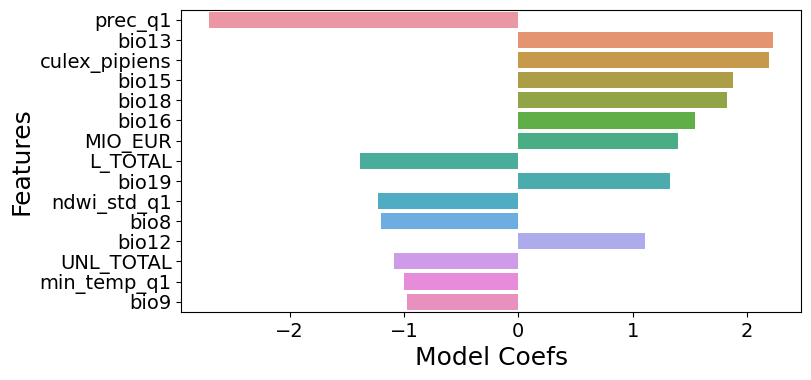

In [19]:
coefs = plot_feature_importance(model_coefficients, feature_names, x_label = 'Model Coefs', top = 15, figure_size = (8, 4))

,features,weights
0,bioclimatic,0.182806
4,vectors,0.115840
1,climate,0.049175
3,demographic,0.046070
2,enviromental,0.037707
5,trade,0.029998
6,economic,0.004920


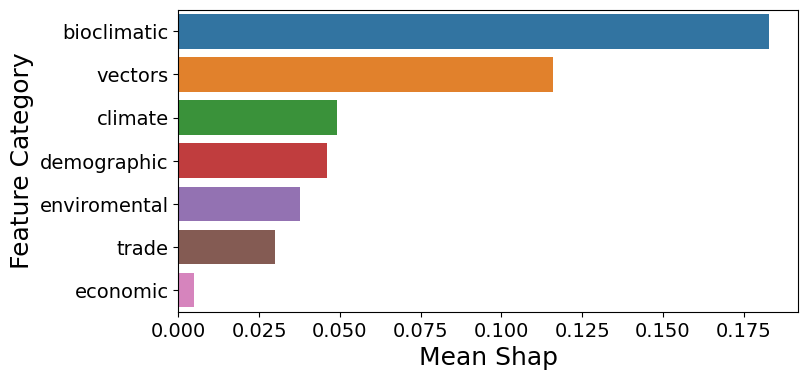

In [20]:
df_bioclimatic = shaps.loc[shaps['features'].isin(bioclimatic)].drop(columns=['weights'])
df_climate = shaps.loc[shaps['features'].isin(climate)].drop(columns=['weights'])
df_enviromental = shaps.loc[shaps['features'].isin(enviromental)].drop(columns=['weights'])
df_demographic = shaps.loc[shaps['features'].isin(demographic)].drop(columns=['weights'])
df_vectors = shaps.loc[shaps['features'].isin(vectors)].drop(columns=['weights'])
df_trade = shaps.loc[shaps['features'].isin(trade)].drop(columns=['weights'])
df_economic = shaps.loc[shaps['features'].isin(economic)].drop(columns=['weights'])

categories = {'Category': ['bioclimatic', 'climate', 'enviromental', 'demographic', 'vectors', 'trade', 'economic'], 
              'Mean_Shap': [df_bioclimatic.weights_abs.sum(),df_climate.weights_abs.sum(),df_enviromental.weights_abs.sum(),
                            df_demographic.weights_abs.sum(),df_vectors.weights_abs.sum(),df_trade.weights_abs.sum(),df_economic.weights_abs.sum()]}

categories_df = pd.DataFrame.from_dict(categories)

categories_df.sort_values(by = 'Mean_Shap', ascending=False)

mean_shap_categories = categories_df['Mean_Shap']
mean_shap_categories = mean_shap_categories.to_numpy().reshape(1,7)

plot_feature_importance(mean_shap_categories, categories_df['Category'], y_label='Feature Category', x_label = 'Mean Shap', figure_size = (8, 4))

,features,weights
4,vectors,0.115840
5,trade,0.014999
1,climate,0.012294
0,bioclimatic,0.009621
3,demographic,0.005759
6,economic,0.004920
2,enviromental,0.003142


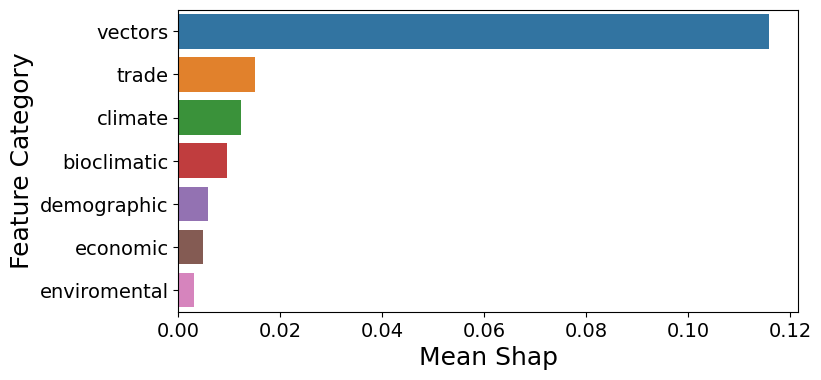

In [21]:
df_bioclimatic = shaps.loc[shaps['features'].isin(bioclimatic)].drop(columns=['weights'])
df_climate = shaps.loc[shaps['features'].isin(climate)].drop(columns=['weights'])
df_enviromental = shaps.loc[shaps['features'].isin(enviromental)].drop(columns=['weights'])
df_demographic = shaps.loc[shaps['features'].isin(demographic)].drop(columns=['weights'])
df_vectors = shaps.loc[shaps['features'].isin(vectors)].drop(columns=['weights'])
df_trade = shaps.loc[shaps['features'].isin(trade)].drop(columns=['weights'])
df_economic = shaps.loc[shaps['features'].isin(economic)].drop(columns=['weights'])

categories = {'Category': ['bioclimatic', 'climate', 'enviromental', 'demographic', 'vectors', 'trade', 'economic'], 
              'Mean_Shap': [df_bioclimatic.weights_abs.mean(),df_climate.weights_abs.mean(),df_enviromental.weights_abs.mean(),
                            df_demographic.weights_abs.mean(),df_vectors.weights_abs.mean(),df_trade.weights_abs.mean(),df_economic.weights_abs.mean()]}

categories_df = pd.DataFrame.from_dict(categories)

categories_df.sort_values(by = 'Mean_Shap', ascending=False)

mean_shap_categories = categories_df['Mean_Shap']
mean_shap_categories = mean_shap_categories.to_numpy().reshape(1,7)

plot_feature_importance(mean_shap_categories, categories_df['Category'], y_label='Feature Category', x_label = 'Mean Shap', figure_size = (8, 4))

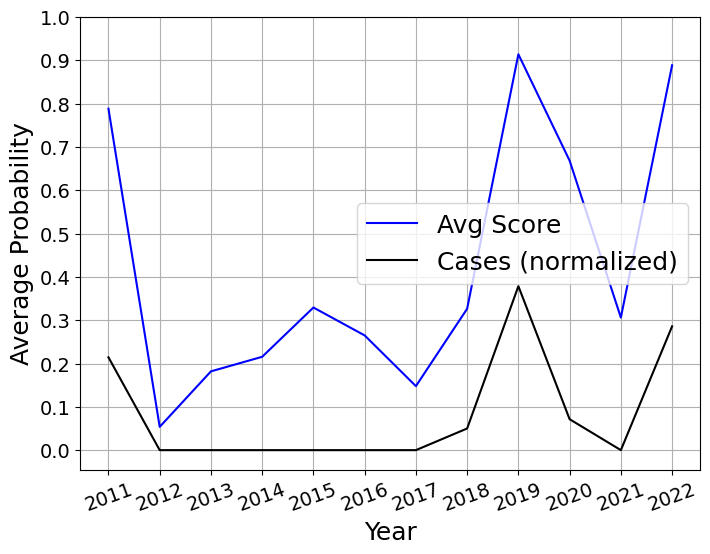

In [22]:
plot_trend_curve(results_test, score_col='score', cases=list(dsc['case']))

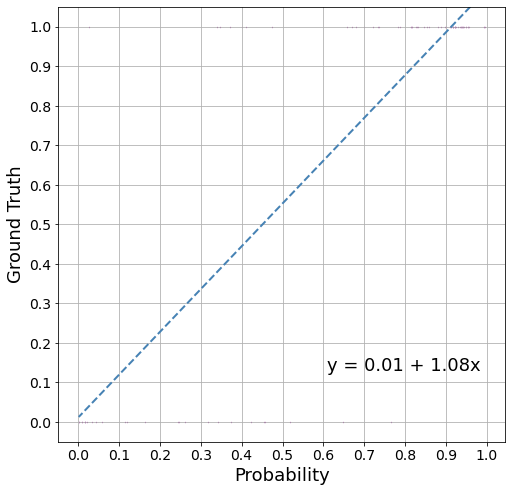

(0.011198545556299254, 1.0832566103662655)

In [23]:
plot_probability_curve(results_test)

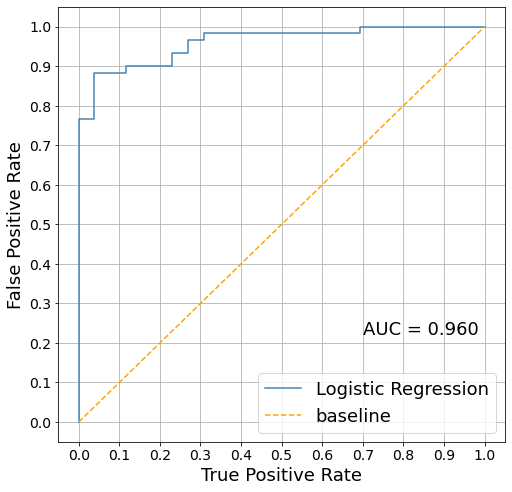

(0.0385, 0.8833, 0.6568, 0.9216)

In [24]:
plot_roc_curve(results_test)

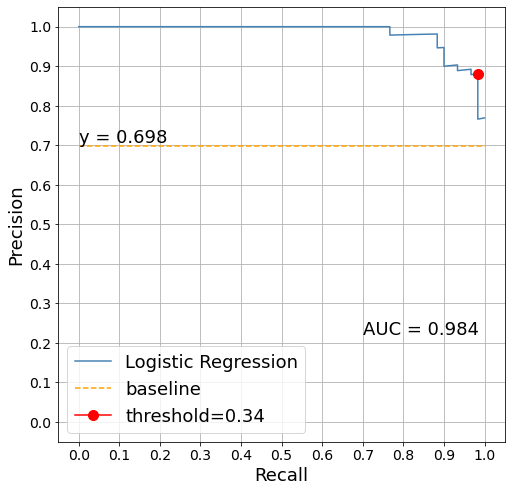

(0.9833, 0.88, 0.34, 0.9609)

In [25]:
plot_pr_curve(results_test, plot_fbeta=True)

In [26]:
results_test

,NUTS3_NAME,year,case,score
0,"καρδιτσα, τρικαλα",2022,1,0.994238
1,"καρδιτσα, τρικαλα",2022,1,0.994083
2,"καρδιτσα, τρικαλα",2022,1,0.993018
3,λαρισα,2022,1,0.957393
4,λαρισα,2022,1,0.953428
...,...,...,...,...
81,"μαγνησια, σποραδες",2015,0,0.015973
82,"μαγνησια, σποραδες",2021,0,0.009581
83,"μαγνησια, σποραδες",2013,0,0.008772
84,"μαγνησια, σποραδες",2012,0,0.002919


In [27]:
results_test['pred_01'] = results_test['score'].apply(lambda x: 1 if x>= 0.1 else 0)
results_test['pred_02'] = results_test['score'].apply(lambda x: 1 if x>= 0.2 else 0)
results_test['pred_05'] = results_test['score'].apply(lambda x: 1 if x>= 0.5 else 0)

In [28]:
results_test

,NUTS3_NAME,year,case,score,pred_01,pred_02,pred_05
0,"καρδιτσα, τρικαλα",2022,1,0.994238,1,1,1
1,"καρδιτσα, τρικαλα",2022,1,0.994083,1,1,1
2,"καρδιτσα, τρικαλα",2022,1,0.993018,1,1,1
3,λαρισα,2022,1,0.957393,1,1,1
4,λαρισα,2022,1,0.953428,1,1,1
...,...,...,...,...,...,...,...
81,"μαγνησια, σποραδες",2015,0,0.015973,0,0,0
82,"μαγνησια, σποραδες",2021,0,0.009581,0,0,0
83,"μαγνησια, σποραδες",2013,0,0.008772,0,0,0
84,"μαγνησια, σποραδες",2012,0,0.002919,0,0,0


In [29]:
accuracy_01 = accuracy_score(results_test.case, results_test.pred_01)
balanced_accuracy_01 = balanced_accuracy_score(results_test.case, results_test.pred_01)
fb_score_01 = fbeta_score(results_test.case, results_test.pred_01, beta = 1, labels = [0,1], zero_division = 0)
precision_01 = precision_score(results_test.case, results_test.pred_01, labels = [0,1], zero_division = 0)
recall_01 = recall_score(results_test.case, results_test.pred_01, labels = [0,1], zero_division = 0)
logloss_01 = log_loss(results_test.case, results_test.score, labels = [0,1])

In [30]:
accuracy_02 = accuracy_score(results_test.case, results_test.pred_02)
balanced_accuracy_02 = balanced_accuracy_score(results_test.case, results_test.pred_02)
fb_score_02 = fbeta_score(results_test.case, results_test.pred_02, beta = 1, labels = [0,1], zero_division = 0)
precision_02 = precision_score(results_test.case, results_test.pred_02, labels = [0,1], zero_division = 0)
recall_02 = recall_score(results_test.case, results_test.pred_02, labels = [0,1], zero_division = 0)
logloss_02 = log_loss(results_test.case, results_test.score, labels = [0,1])

In [31]:
accuracy_05 = accuracy_score(results_test.case, results_test.pred_05)
balanced_accuracy_05 = balanced_accuracy_score(results_test.case, results_test.pred_05)
fb_score_05 = fbeta_score(results_test.case, results_test.pred_05, beta = 1, labels = [0,1], zero_division = 0)
precision_05 = precision_score(results_test.case, results_test.pred_05, labels = [0,1], zero_division = 0)
recall_05 = recall_score(results_test.case, results_test.pred_05, labels = [0,1], zero_division = 0)
logloss_05 = log_loss(results_test.case, results_test.score, labels = [0,1])

In [32]:
thr_01 = {'accuracy': accuracy_01, 'balanced_accuracy': balanced_accuracy_01, 
          'f1_score': fb_score_01, 'precision': precision_01, 'recall': recall_01, 'logloss': logloss_01}

thr_02 = {'accuracy': accuracy_02, 'balanced_accuracy': balanced_accuracy_02, 
          'f1_score': fb_score_02, 'precision': precision_02, 'recall': recall_02, 'logloss': logloss_02}

thr_05 = {'accuracy': accuracy_05, 'balanced_accuracy': balanced_accuracy_05, 
          'f1_score': fb_score_05, 'precision': precision_05, 'recall': recall_05, 'logloss': logloss_05}

In [33]:
results_df = pd.DataFrame([thr_01, thr_02, thr_05])
results_df.index = ['Threshold: 0.1', 'Threshold: 0.2', 'Threshold: 0.5']

In [34]:
results_df

,accuracy,balanced_accuracy,f1_score,precision,recall,logloss
Threshold: 0.1,0.813953,0.703205,0.880597,0.797297,0.983333,0.283793
Threshold: 0.2,0.848837,0.760897,0.900763,0.830986,0.983333,0.283793
Threshold: 0.5,0.883721,0.883974,0.913793,0.946429,0.883333,0.283793
